# Feature Engineering Pipeline

Demonstrating the complete feature engineering pipeline:
- Missing value imputation
- Numerical scaling (StandardScaler)
- Categorical one-hot encoding
- Feature store materialization

In [1]:
import sys
sys.path.insert(0, '..')

from src.data.ingestion import DataIngestion
from src.data.splitter import DataSplitter
from src.features.feature_store import FeatureStore
from src.features.transformers import FeatureTransformer
from src.features.feature_definitions import FEATURE_SCHEMA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ingestion        = DataIngestion()
df               = ingestion.load()
splitter         = DataSplitter()
train, val, test = splitter.split(df)

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
print(f"Features: {FEATURE_SCHEMA.feature_count}")
print(f"Numerical: {FEATURE_SCHEMA.numerical_features}")
print(f"Categorical: {FEATURE_SCHEMA.categorical_features}")

2026-07-01 13:06:42 | INFO | src.data.ingestion | Using cached dataset
2026-07-01 13:06:42 | INFO | src.data.ingestion | Dataset loaded
2026-07-01 13:06:42 | INFO | src.data.splitter | Data split complete
2026-07-01 13:06:42 | INFO | src.data.splitter | Class ratio in train
2026-07-01 13:06:42 | INFO | src.data.splitter | Class ratio in val
2026-07-01 13:06:42 | INFO | src.data.splitter | Class ratio in test
Train: 22792, Val: 3256, Test: 6513
Features: 14
Numerical: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']


2026-07-01 13:06:51 | INFO | src.features.transformers | Fitting feature transformer
2026-07-01 13:06:52 | INFO | src.features.transformers | Feature transformer fitted


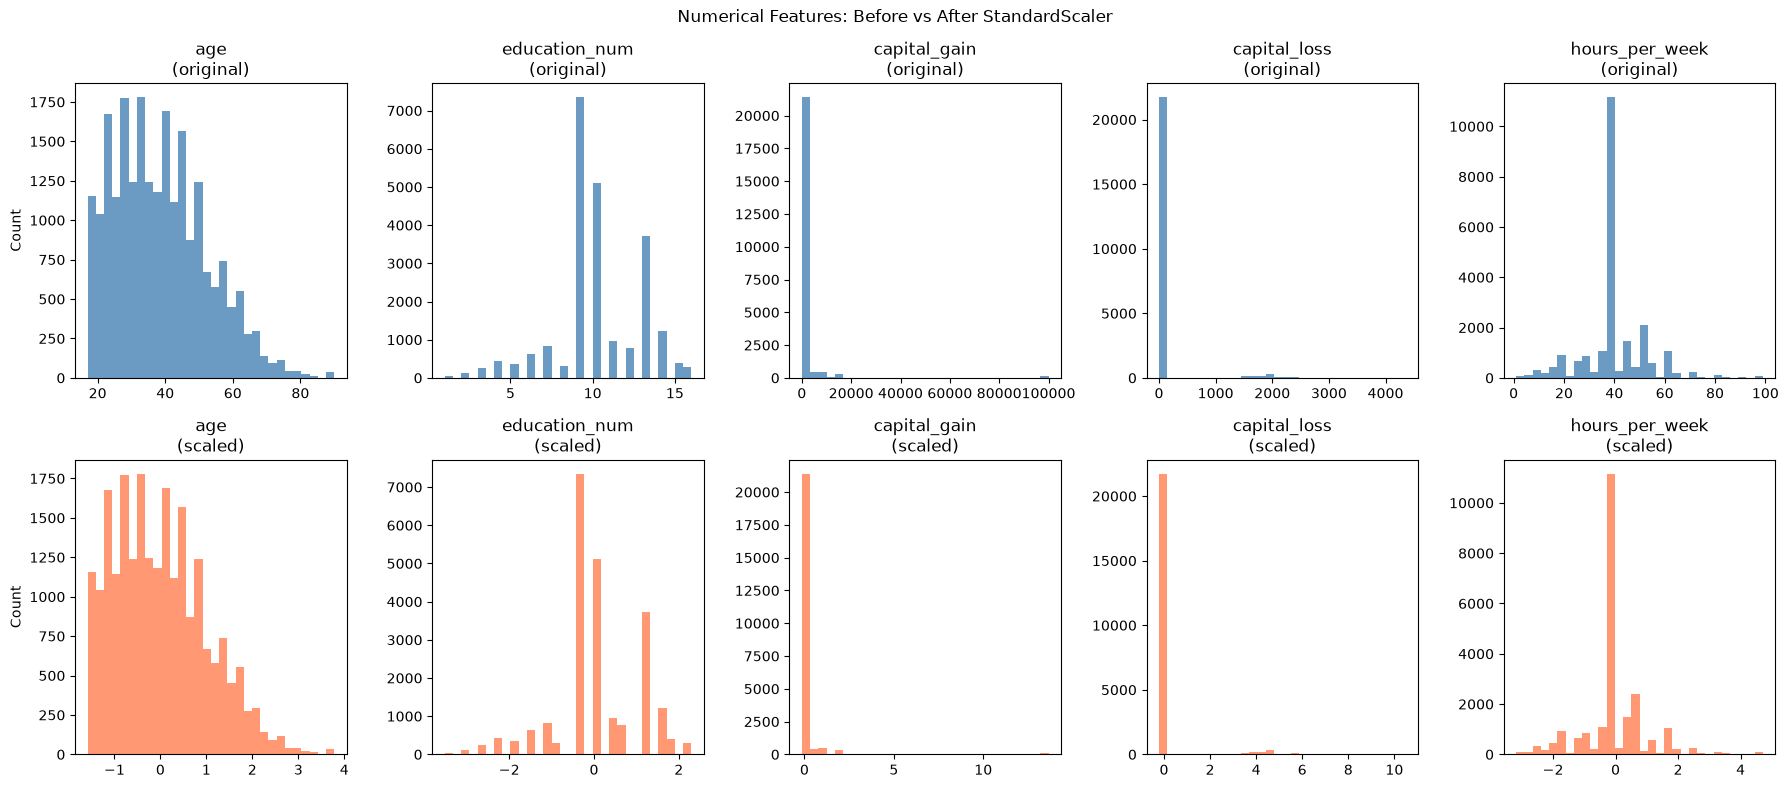


Before scaling - age mean: 38.57, std: 13.60
After scaling  - age mean: 0.0000, std: 1.0000


In [2]:
transformer = FeatureTransformer()
X_train = transformer.fit_transform(train)

numerical_features = transformer.numerical_features

fig, axes = plt.subplots(2, len(numerical_features), figsize=(18, 8))
fig.suptitle("Numerical Features: Before vs After StandardScaler", fontsize=12)

for i, col in enumerate(numerical_features):
    # Before scaling
    axes[0, i].hist(train[col].dropna(), bins=30, color="steelblue", alpha=0.8)
    axes[0, i].set_title(f"{col}\n(original)")
    axes[0, i].set_ylabel("Count" if i == 0 else "")

    # After scaling (first len(numerical_features) columns are numerical)
    axes[1, i].hist(X_train[:, i], bins=30, color="coral", alpha=0.8)
    axes[1, i].set_title(f"{col}\n(scaled)")
    axes[1, i].set_ylabel("Count" if i == 0 else "")

plt.tight_layout()
plt.savefig("../data/feature_scaling.png", dpi=150)
plt.show()

print(f"\nBefore scaling - age mean: {train['age'].mean():.2f}, std: {train['age'].std():.2f}")
print(f"After scaling  - age mean: {X_train[:, 0].mean():.4f}, std: {X_train[:, 0].std():.4f}")

In [3]:
store = FeatureStore()
store.materialize(train, val, test)

X_train, X_val, X_test, y_train, y_val, y_test = store.get_training_features()
feature_names = store.get_feature_names()

print(f"X_train shape: {X_train.shape}")
print(f"Total features after encoding: {len(feature_names)}")
print(f"\nFeature breakdown:")
print(f"  Numerical (scaled):     {len(transformer.numerical_features)}")
print(f"  One-hot encoded:        {len(feature_names) - len(transformer.numerical_features)}")
print(f"\nSample feature names:")
print(f"  {feature_names[:5]}")
print(f"  ...")
print(f"  {feature_names[-5:]}")

2026-07-01 13:07:07 | INFO | src.features.feature_store | Initialized FeatureStore
2026-07-01 13:07:07 | INFO | src.features.feature_store | Materializing features
2026-07-01 13:07:07 | INFO | src.features.transformers | Fitting feature transformer
2026-07-01 13:07:07 | INFO | src.features.transformers | Feature transformer fitted
2026-07-01 13:07:07 | INFO | src.features.feature_store | Features materialized
2026-07-01 13:07:07 | INFO | src.features.feature_store | Loaded features from store
X_train shape: (22792, 88)
Total features after encoding: 88

Feature breakdown:
  Numerical (scaled):     5
  One-hot encoded:        83

Sample feature names:
  ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
  ...
  ['native_country_Thailand', 'native_country_Trinadad&Tobago', 'native_country_United-States', 'native_country_Vietnam', 'native_country_Yugoslavia']


In [4]:
entity = {
    "age": 35, "workclass": "Private", "fnlwgt": 200000,
    "education": "Bachelors", "education_num": 13,
    "marital_status": "Married-civ-spouse", "occupation": "Tech-support",
    "relationship": "Husband", "race": "White", "sex": "Male",
    "capital_gain": 5000, "capital_loss": 0, "hours_per_week": 40,
    "native_country": "United-States", "income": "<=50K",
}

online_features = store.get_online_features(entity)
print(f"Online feature vector shape: {online_features.shape}")
print(f"First 10 values: {online_features[0, :10].round(4)}")
print("\nFeature pipeline ready for real-time inference!")

Online feature vector shape: (1, 88)
First 10 values: [-0.2623  1.1329  0.545  -0.2174 -0.0392  0.      0.      0.      1.
  0.    ]

Feature pipeline ready for real-time inference!
